#Customer Segment Performance Report

##Importing the Libraries

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Datasets

In [10]:
segment_df = pd.read_excel("Segmented_Cohortdataset.xlsx")
summary_df = pd.read_excel("AOV_PurchaseFrequency_Summary.xlsx")
cltv_df = pd.read_excel("Historical_CLTV_By_Region.xlsx")

## Calculate Region-wise Metrics

In [11]:
region_summary = segment_df.groupby("RegionSegment").agg(
    Total_Customers=("CustomerID", "nunique"),
    Total_Orders=("InvoiceNo", "nunique"),
    Total_Revenue=("Revenue", "sum")
).reset_index()

## Merge with AOV & Purchase Frequency

In [13]:
performance = pd.merge(
    region_summary,
    summary_df[["RegionSegment",
                "Average_Order_Value",
                "Purchase_Frequency"]],
    on="RegionSegment"
)

## Merge with Historical CLTV

In [15]:
performance = pd.merge(
    performance,
    cltv_df[["RegionSegment", "Historical_CLTV"]],
    on="RegionSegment"
)

## Rank Regions

In [17]:
performance["Revenue_Rank"] = performance["Total_Revenue"].rank(
    ascending=False,
    method="dense"
).astype(int)

performance["CLTV_Rank"] = performance["Historical_CLTV"].rank(
    ascending=False,
    method="dense"
).astype(int)

## Display Performance Report

In [18]:
print("\nCustomer Segment Performance Report")
print(performance)


Customer Segment Performance Report
  RegionSegment  Total_Customers  Total_Orders  Total_Revenue  \
0        Europe              186           615     462471.320   
1         Other              128           425     464744.970   
2            UK             2908          9623    3959382.112   

   Average_Order_Value  Purchase_Frequency  Historical_CLTV  Revenue_Rank  \
0               751.99                3.31          2489.09             3   
1              1093.52                3.32          3630.49             2   
2               411.45                3.31          1361.90             1   

   CLTV_Rank  
0          2  
1          1  
2          3  


## Performance Comparison Chart

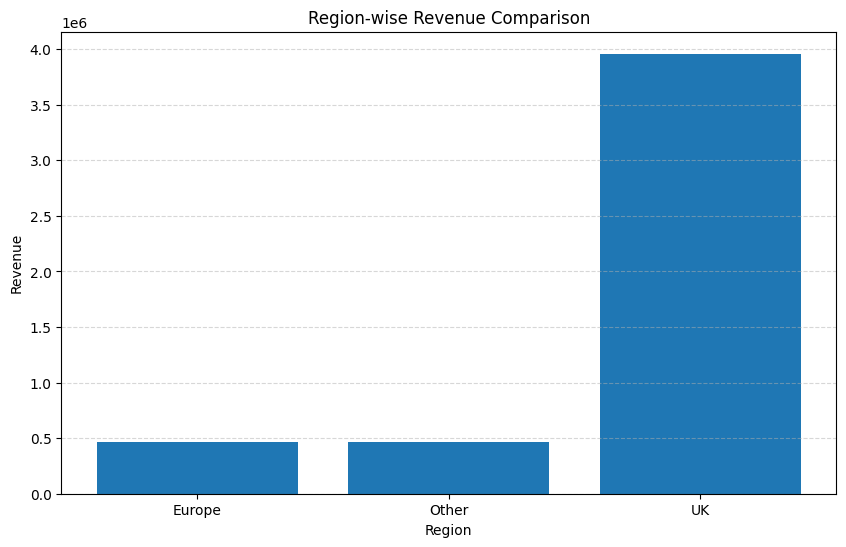

In [19]:
plt.figure(figsize=(10,6))

plt.bar(
    performance["RegionSegment"],
    performance["Total_Revenue"],
    label="Revenue"
)

plt.title("Region-wise Revenue Comparison")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Customer Segment KPI Comparison

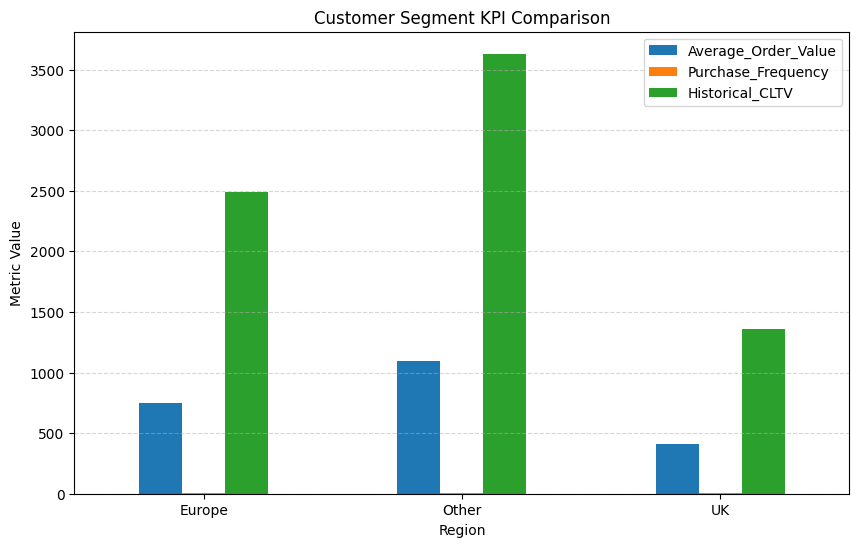

In [24]:
comparison = performance.set_index("RegionSegment")[[
    "Average_Order_Value",
    "Purchase_Frequency",
    "Historical_CLTV"
]]

comparison.plot(kind="bar", figsize=(10,6))
plt.title("Customer Segment KPI Comparison")
plt.xlabel("Region")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Highest Revenue Region

In [20]:
highest_revenue = performance.loc[
    performance["Total_Revenue"].idxmax()
]

print("\nHighest Revenue Region")
print(highest_revenue[[
    "RegionSegment",
    "Total_Revenue"
]])



Highest Revenue Region
RegionSegment             UK
Total_Revenue    3959382.112
Name: 2, dtype: object


## Highest CLTV Region

In [22]:
highest_cltv = performance.loc[
    performance["Historical_CLTV"].idxmax()
]

print("\nHighest Historical CLTV Region")
print(highest_cltv[[
    "RegionSegment",
    "Historical_CLTV"
]])


Highest Historical CLTV Region
RegionSegment        Other
Historical_CLTV    3630.49
Name: 1, dtype: object
